In [4]:
import pandas as pd
from pathlib import Path

In [125]:
import re
import numpy as np
import pandas as pd
from pathlib import Path

# ----------------------------
# Config
# ----------------------------
root_path = Path("/home/kkondo/code/dynus_ws/src/dynus/benchmark_data")

folders = {
    "single_thread": [
        "dynus_4_benchmark.csv",
        "dynus_5_benchmark.csv",
        "dynus_6_benchmark.csv",
        "faster_4_benchmark.csv",
        "faster_5_benchmark.csv",
        "faster_6_benchmark.csv",
    ],
    "multi_thread": [
        "dynus_4_benchmark.csv",
        "dynus_5_benchmark.csv",
        "dynus_6_benchmark.csv",
        "dynus_star_4_benchmark.csv",
        "dynus_star_5_benchmark.csv",
        "dynus_star_6_benchmark.csv",
        "faster_4_benchmark.csv",
        "faster_5_benchmark.csv",
        "faster_6_benchmark.csv",
    ],
}

SERIES = [
    {"label": "faster (single)",     "mode": "single_thread", "planner": "faster"},
    {"label": "dynus (single)",      "mode": "single_thread", "planner": "dynus"},
    {"label": "dynus (multi)",       "mode": "multi_thread",  "planner": "dynus"},
    {"label": "dynus_star (multi)",  "mode": "multi_thread",  "planner": "dynus_star"},
]

# Required mean columns for dynus/faster (over successful runs)
DYN_REQUIRED_MEAN_COLS = [
    "per_opt_runtime_ms",
    "total_opt_runtime_ms",
    "total_traj_time_sec",
]

# SUPER has no total_opt_runtime_ms (per your note), but has total_traj_time_sec
SUPER_MEAN_COLS = [
    "per_opt_runtime_ms",
    "total_traj_time_sec",
]

SMOOTHNESS_COLS = ["jerk_smoothness_l1", "jerk_rms"]
LENGTH_COLS = ["traj_length_m"]

# Violation-rate columns for dynus/faster (booleans)
DYN_VIOL_BOOL_COLS = {
    "sfc": "corridor_violated",
    "v":   "v_violated",
    "a":   "a_violated",
    "j":   "j_violated",
}

# Max-violation magnitude columns for dynus/faster (scalars per case)
DYN_MAX_VIOL_COLS = {
    "sfc": "corridor_max_min_violation",
    "v":   "v_max_excess",
    "a":   "a_max_excess",
    "j":   "j_max_excess",
}

# SUPER CSV
SUPER_CSV_PATH = Path("/media/kkondo/kota_elements/super/super_local_traj_benchmark.csv")
SUPER_VIOL_VAL_COLS = {
    "sfc": "max_sfc_violation",
    "v":   "max_vel_violation",
    "a":   "max_acc_violation",
    "j":   "max_jerk_violation",
}
SUPER_TOL = 1e-3  # violation if > tol

# ----------------------------
# Helpers
# ----------------------------
def parse_success(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.integer, np.floating)):
        return int(x)
    s = str(x).strip().lower()
    if s in {"1", "true", "t", "yes", "y", "ok", "success"}:
        return 1
    if s in {"0", "false", "f", "no", "n", "fail", "failure"}:
        return 0
    try:
        return int(float(s))
    except Exception:
        return np.nan

pat = re.compile(r"^(?P<planner>.+)_(?P<N>\d+)_benchmark\.csv$")

def series_mask(df, mode, planner):
    return (df["mode"] == mode) & (df["planner_from_file"] == planner)

def add_series_label(df):
    df = df.copy()
    df["series_label"] = None
    for s in SERIES:
        mask = series_mask(df, s["mode"], s["planner"])
        df.loc[mask, "series_label"] = s["label"]
    return df

def safe_mean(series):
    if series is None:
        return np.nan
    s = series.dropna()
    if s.empty:
        return np.nan
    return float(s.mean())

def as_bool01(series):
    if series is None:
        return None
    if series.dtype == bool:
        return series.astype(float)
    return pd.to_numeric(series, errors="coerce")

def fmt_cell(x):
    """Print '-' for NaN, else numeric with 6 decimals; keep strings unchanged."""
    if isinstance(x, str):
        return x
    if x is None:
        return "-"
    try:
        if pd.isna(x):
            return "-"
    except Exception:
        pass
    try:
        return f"{float(x):.4f}"
    except Exception:
        return str(x)

# ----------------------------
# Load dynus/faster CSVs
# ----------------------------
dfs = []
missing = []

for mode, files in folders.items():
    for f in files:
        m = pat.match(f)
        if not m:
            raise ValueError(f"Filename does not match '<planner>_<N>_benchmark.csv': {f}")

        planner_from_file = m.group("planner")
        N_from_file = int(m.group("N"))

        path = root_path / mode / f
        if not path.exists():
            missing.append(str(path))
            continue

        df = pd.read_csv(path)
        df["mode"] = mode
        df["source_csv"] = f
        df["planner_from_file"] = planner_from_file
        df["N"] = N_from_file
        dfs.append(df)

if missing:
    print("WARNING: missing dynus/faster CSVs were skipped:")
    for p in missing:
        print("  ", p)

if not dfs:
    raise RuntimeError("No dynus/faster CSVs loaded. Check root_path/folder structure and filenames.")

data_all = pd.concat(dfs, ignore_index=True)

# ----------------------------
# Clean dynus/faster columns
# ----------------------------
if "success" not in data_all.columns:
    raise KeyError("Column 'success' not found in dynus/faster CSV(s).")
data_all["success"] = data_all["success"].apply(parse_success)

# Required dynus/faster mean cols
for c in DYN_REQUIRED_MEAN_COLS:
    if c not in data_all.columns:
        raise KeyError(f"Column '{c}' not found in dynus/faster CSV(s).")
    data_all[c] = pd.to_numeric(data_all[c], errors="coerce")

# Optional metrics
for c in SMOOTHNESS_COLS + LENGTH_COLS:
    if c in data_all.columns:
        data_all[c] = pd.to_numeric(data_all[c], errors="coerce")

# Violation rates and max magnitudes
for c in DYN_VIOL_BOOL_COLS.values():
    if c in data_all.columns:
        data_all[c] = as_bool01(data_all[c])

for c in DYN_MAX_VIOL_COLS.values():
    if c in data_all.columns:
        data_all[c] = pd.to_numeric(data_all[c], errors="coerce")

# Add labels and keep only selected series
data_all = add_series_label(data_all)
data_all = data_all[data_all["series_label"].notna()].copy()

# Known attempts for denominators
known_mask = data_all["success"].isin([0, 1])
data_known = data_all.loc[known_mask].copy()

# ----------------------------
# Build dynus/faster summary rows
# ----------------------------
rows = []

have_dyn_viol_rates = all(col in data_known.columns for col in DYN_VIOL_BOOL_COLS.values())
have_dyn_max_viol = all(col in data_known.columns for col in DYN_MAX_VIOL_COLS.values())

for (series_label, N), g in data_known.groupby(["series_label", "N"], sort=True):
    opt_success_rate = safe_mean(g["success"])

    # violation rates among successful optimizations
    sfc_violate_rate = np.nan
    v_violate_rate = np.nan
    a_violate_rate = np.nan
    j_violate_rate = np.nan

    # trajectory success rate: success AND no constraint violations
    traj_success_rate = np.nan
    if have_dyn_viol_rates:
        g_succ = g[g["success"] == 1].copy()

        if not g_succ.empty:
            sfc_violate_rate = safe_mean(g_succ[DYN_VIOL_BOOL_COLS["sfc"]])
            v_violate_rate   = safe_mean(g_succ[DYN_VIOL_BOOL_COLS["v"]])
            a_violate_rate   = safe_mean(g_succ[DYN_VIOL_BOOL_COLS["a"]])
            j_violate_rate   = safe_mean(g_succ[DYN_VIOL_BOOL_COLS["j"]])

        safe_mask = (
            (g["success"] == 1)
            & (g[DYN_VIOL_BOOL_COLS["sfc"]] == 0)
            & (g[DYN_VIOL_BOOL_COLS["v"]] == 0)
            & (g[DYN_VIOL_BOOL_COLS["a"]] == 0)
            & (g[DYN_VIOL_BOOL_COLS["j"]] == 0)
        )
        traj_success_rate = float(safe_mask.mean()) if len(g) > 0 else np.nan

    # means over successful runs
    g_succ = g[g["success"] == 1].copy()

    def mean_over_success(col):
        if col in g_succ.columns and not g_succ.empty:
            return safe_mean(g_succ[col])
        return np.nan

    # mean max violation magnitudes across all cases (NaN-skip)
    mean_max_sfc_violation = np.nan
    mean_max_v_violation = np.nan
    mean_max_a_violation = np.nan
    mean_max_j_violation = np.nan
    if have_dyn_max_viol:
        mean_max_sfc_violation = safe_mean(g[DYN_MAX_VIOL_COLS["sfc"]])
        mean_max_v_violation   = safe_mean(g[DYN_MAX_VIOL_COLS["v"]])
        mean_max_a_violation   = safe_mean(g[DYN_MAX_VIOL_COLS["a"]])
        mean_max_j_violation   = safe_mean(g[DYN_MAX_VIOL_COLS["j"]])

    rows.append({
        "planner_name": series_label,
        "N": int(N),
        "success_rate": opt_success_rate,
        "traj_success_rate": traj_success_rate,
        "per_opt_runtime_ms": mean_over_success("per_opt_runtime_ms"),
        "total_opt_runtime_ms": mean_over_success("total_opt_runtime_ms"),
        "total_traj_time_sec": mean_over_success("total_traj_time_sec"),
        "jerk_smoothness_l1": mean_over_success("jerk_smoothness_l1"),
        "jerk_rms": mean_over_success("jerk_rms"),
        "traj_length_m": mean_over_success("traj_length_m"),
        "sfc_violate_rate": sfc_violate_rate,
        "v_violate_rate": v_violate_rate,
        "a_violate_rate": a_violate_rate,
        "j_violate_rate": j_violate_rate,
        "mean_max_sfc_violation": mean_max_sfc_violation,
        "mean_max_v_violation": mean_max_v_violation,
        "mean_max_a_violation": mean_max_a_violation,
        "mean_max_j_violation": mean_max_j_violation,
    })

dyn_table = pd.DataFrame(rows)
fmt_cell
super_row = None
if SUPER_CSV_PATH.exists():
    super_df = pd.read_csv(SUPER_CSV_PATH)

    if "success" not in super_df.columns:
        raise KeyError("Column 'success' not found in SUPER CSV.")
    super_df["success"] = super_df["success"].apply(parse_success)

    # Coerce numeric fields that exist in SUPER schema
    for c in SUPER_MEAN_COLS + SMOOTHNESS_COLS + LENGTH_COLS + list(SUPER_VIOL_VAL_COLS.values()):
        if c in super_df.columns:
            super_df[c] = pd.to_numeric(super_df[c], errors="coerce")

    super_known = super_df["success"].isin([0, 1])
    g = super_df.loc[super_known].copy()

    opt_success_rate = safe_mean(g["success"])

    have_super_viol_vals = all(c in g.columns for c in SUPER_VIOL_VAL_COLS.values())

    # trajectory success rate: success and all max_*_violation <= tol
    traj_success_rate = np.nan
    if have_super_viol_vals:
        safe_mask = (
            (g["success"] == 1)
            & (g[SUPER_VIOL_VAL_COLS["sfc"]] <= SUPER_TOL)
            & (g[SUPER_VIOL_VAL_COLS["v"]]   <= SUPER_TOL)
            & (g[SUPER_VIOL_VAL_COLS["a"]]   <= SUPER_TOL)
            & (g[SUPER_VIOL_VAL_COLS["j"]]   <= SUPER_TOL)
        )
        traj_success_rate = float(safe_mask.mean()) if len(g) > 0 else np.nan

    g_succ = g[g["success"] == 1].copy()

    def mean_over_success_super(col):
        if col in g_succ.columns and not g_succ.empty:
            return safe_mean(g_succ[col])
        return np.nan

    # violation rates among successful optimizations
    sfc_violate_rate = np.nan
    v_violate_rate = np.nan
    a_violate_rate = np.nan
    j_violate_rate = np.nan
    if have_super_viol_vals and not g_succ.empty:
        sfc_violate_rate = safe_mean((g_succ[SUPER_VIOL_VAL_COLS["sfc"]] > SUPER_TOL).astype(float))
        v_violate_rate   = safe_mean((g_succ[SUPER_VIOL_VAL_COLS["v"]]   > SUPER_TOL).astype(float))
        a_violate_rate   = safe_mean((g_succ[SUPER_VIOL_VAL_COLS["a"]]   > SUPER_TOL).astype(float))
        j_violate_rate   = safe_mean((g_succ[SUPER_VIOL_VAL_COLS["j"]]   > SUPER_TOL).astype(float))

    # mean max-violation magnitudes across all cases (NaN-skip)
    mean_max_sfc_violation = safe_mean(g[SUPER_VIOL_VAL_COLS["sfc"]]) if have_super_viol_vals else np.nan
    mean_max_v_violation   = safe_mean(g[SUPER_VIOL_VAL_COLS["v"]])   if have_super_viol_vals else np.nan
    mean_max_a_violation   = safe_mean(g[SUPER_VIOL_VAL_COLS["a"]])   if have_super_viol_vals else np.nan
    mean_max_j_violation   = safe_mean(g[SUPER_VIOL_VAL_COLS["j"]])   if have_super_viol_vals else np.nan

    super_row = {
        "planner_name": "super",
        "N": "-",
        "success_rate": opt_success_rate,
        "traj_success_rate": traj_success_rate,
        "per_opt_runtime_ms": mean_over_success_super("per_opt_runtime_ms"),
        # USER REQUEST: SUPER has no total_opt_runtime_ms -> print '-'
        "total_opt_runtime_ms": "-",
        # USER REQUEST: SUPER total_traj_time_sec exists -> compute mean over successful runs
        "total_traj_time_sec": mean_over_success_super("total_traj_time_sec"),
        "jerk_smoothness_l1": mean_over_success_super("jerk_smoothness_l1"),
        "jerk_rms": mean_over_success_super("jerk_rms"),
        "traj_length_m": mean_over_success_super("traj_length_m"),
        "sfc_violate_rate": sfc_violate_rate,
        "v_violate_rate": v_violate_rate,
        "a_violate_rate": a_violate_rate,
        "j_violate_rate": j_violate_rate,
        "mean_max_sfc_violation": mean_max_sfc_violation,
        "mean_max_v_violation": mean_max_v_violation,
        "mean_max_a_violation": mean_max_a_violation,
        "mean_max_j_violation": mean_max_j_violation,
    }
else:
    print("WARNING: SUPER CSV not found at:", str(SUPER_CSV_PATH))

# ----------------------------
# Final table print
# ----------------------------
final_cols = [
    "planner_name",
    "N",
    "success_rate",
    "traj_success_rate",
    "per_opt_runtime_ms",
    "total_opt_runtime_ms",
    "total_traj_time_sec",
    "jerk_smoothness_l1",
    "jerk_rms",
    "traj_length_m",
    "sfc_violate_rate",
    "v_violate_rate",
    "a_violate_rate",
    "j_violate_rate",
    "mean_max_sfc_violation",
    "mean_max_v_violation",
    "mean_max_a_violation",
    "mean_max_j_violation",
]

out_tbl = dyn_table.copy()
if super_row is not None:
    out_tbl = pd.concat([out_tbl, pd.DataFrame([super_row])], ignore_index=True)

for c in final_cols:
    if c not in out_tbl.columns:
        out_tbl[c] = np.nan

def sort_key_N(x):
    try:
        return int(x)
    except Exception:
        return 10**9

out_tbl["_N_sort"] = out_tbl["N"].apply(sort_key_N)
out_tbl["_is_super"] = (out_tbl["planner_name"] == "super").astype(int)
out_tbl = out_tbl.sort_values(["_is_super", "_N_sort", "planner_name"]).drop(columns=["_N_sort", "_is_super"])

print("\n=== Unified Benchmark Summary Table (SUPER total_opt_runtime_ms='-') ===")
print(out_tbl[final_cols].applymap(fmt_cell).to_string(index=False))

# Warnings if expected columns are missing
missing_rate_cols = [c for c in DYN_VIOL_BOOL_COLS.values() if c not in data_known.columns]
if missing_rate_cols:
    print("\nWARNING: dynus/faster missing violation-rate columns:", missing_rate_cols)

missing_max_cols = [c for c in DYN_MAX_VIOL_COLS.values() if c not in data_known.columns]
if missing_max_cols:
    print("\nWARNING: dynus/faster missing max-violation magnitude columns:", missing_max_cols)



=== Unified Benchmark Summary Table (SUPER total_opt_runtime_ms='-') ===
      planner_name      N success_rate traj_success_rate per_opt_runtime_ms total_opt_runtime_ms total_traj_time_sec jerk_smoothness_l1 jerk_rms traj_length_m sfc_violate_rate v_violate_rate a_violate_rate j_violate_rate mean_max_sfc_violation mean_max_v_violation mean_max_a_violation mean_max_j_violation
     dynus (multi) 4.0000       0.7624            0.7624             3.0851              16.5218             22.9818             0.7905   0.0403        8.7126           0.0000         0.0000         0.0000         0.0000                -0.1617               0.0000               0.0000               0.0000
    dynus (single) 4.0000       0.7624            0.7624             1.8931              29.5851             22.4519             0.8344   0.0436        8.7232           0.0000         0.0000         0.0000         0.0000                -0.1495               0.0000               0.0000               0.0000
dynus

/tmp/ipykernel_9821/862411272.py:419: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(out_tbl[final_cols].applymap(fmt_cell).to_string(index=False))


[WARN] Missing file, using placeholder: /home/kkondo/paper_writing/DYNUS_v3/figures/sim/standardized/dynus_case_different1.png
[WARN] Missing file, using placeholder: /home/kkondo/paper_writing/DYNUS_v3/figures/sim/standardized/dynus_case_super_inefficient1.png
[WARN] Missing file, using placeholder: /home/kkondo/paper_writing/DYNUS_v3/figures/sim/standardized/dynus_case_super_inefficient4.png
[OK] Saved: /home/kkondo/paper_writing/DYNUS_v3/figures/sim/standardized/combined_standardized.png


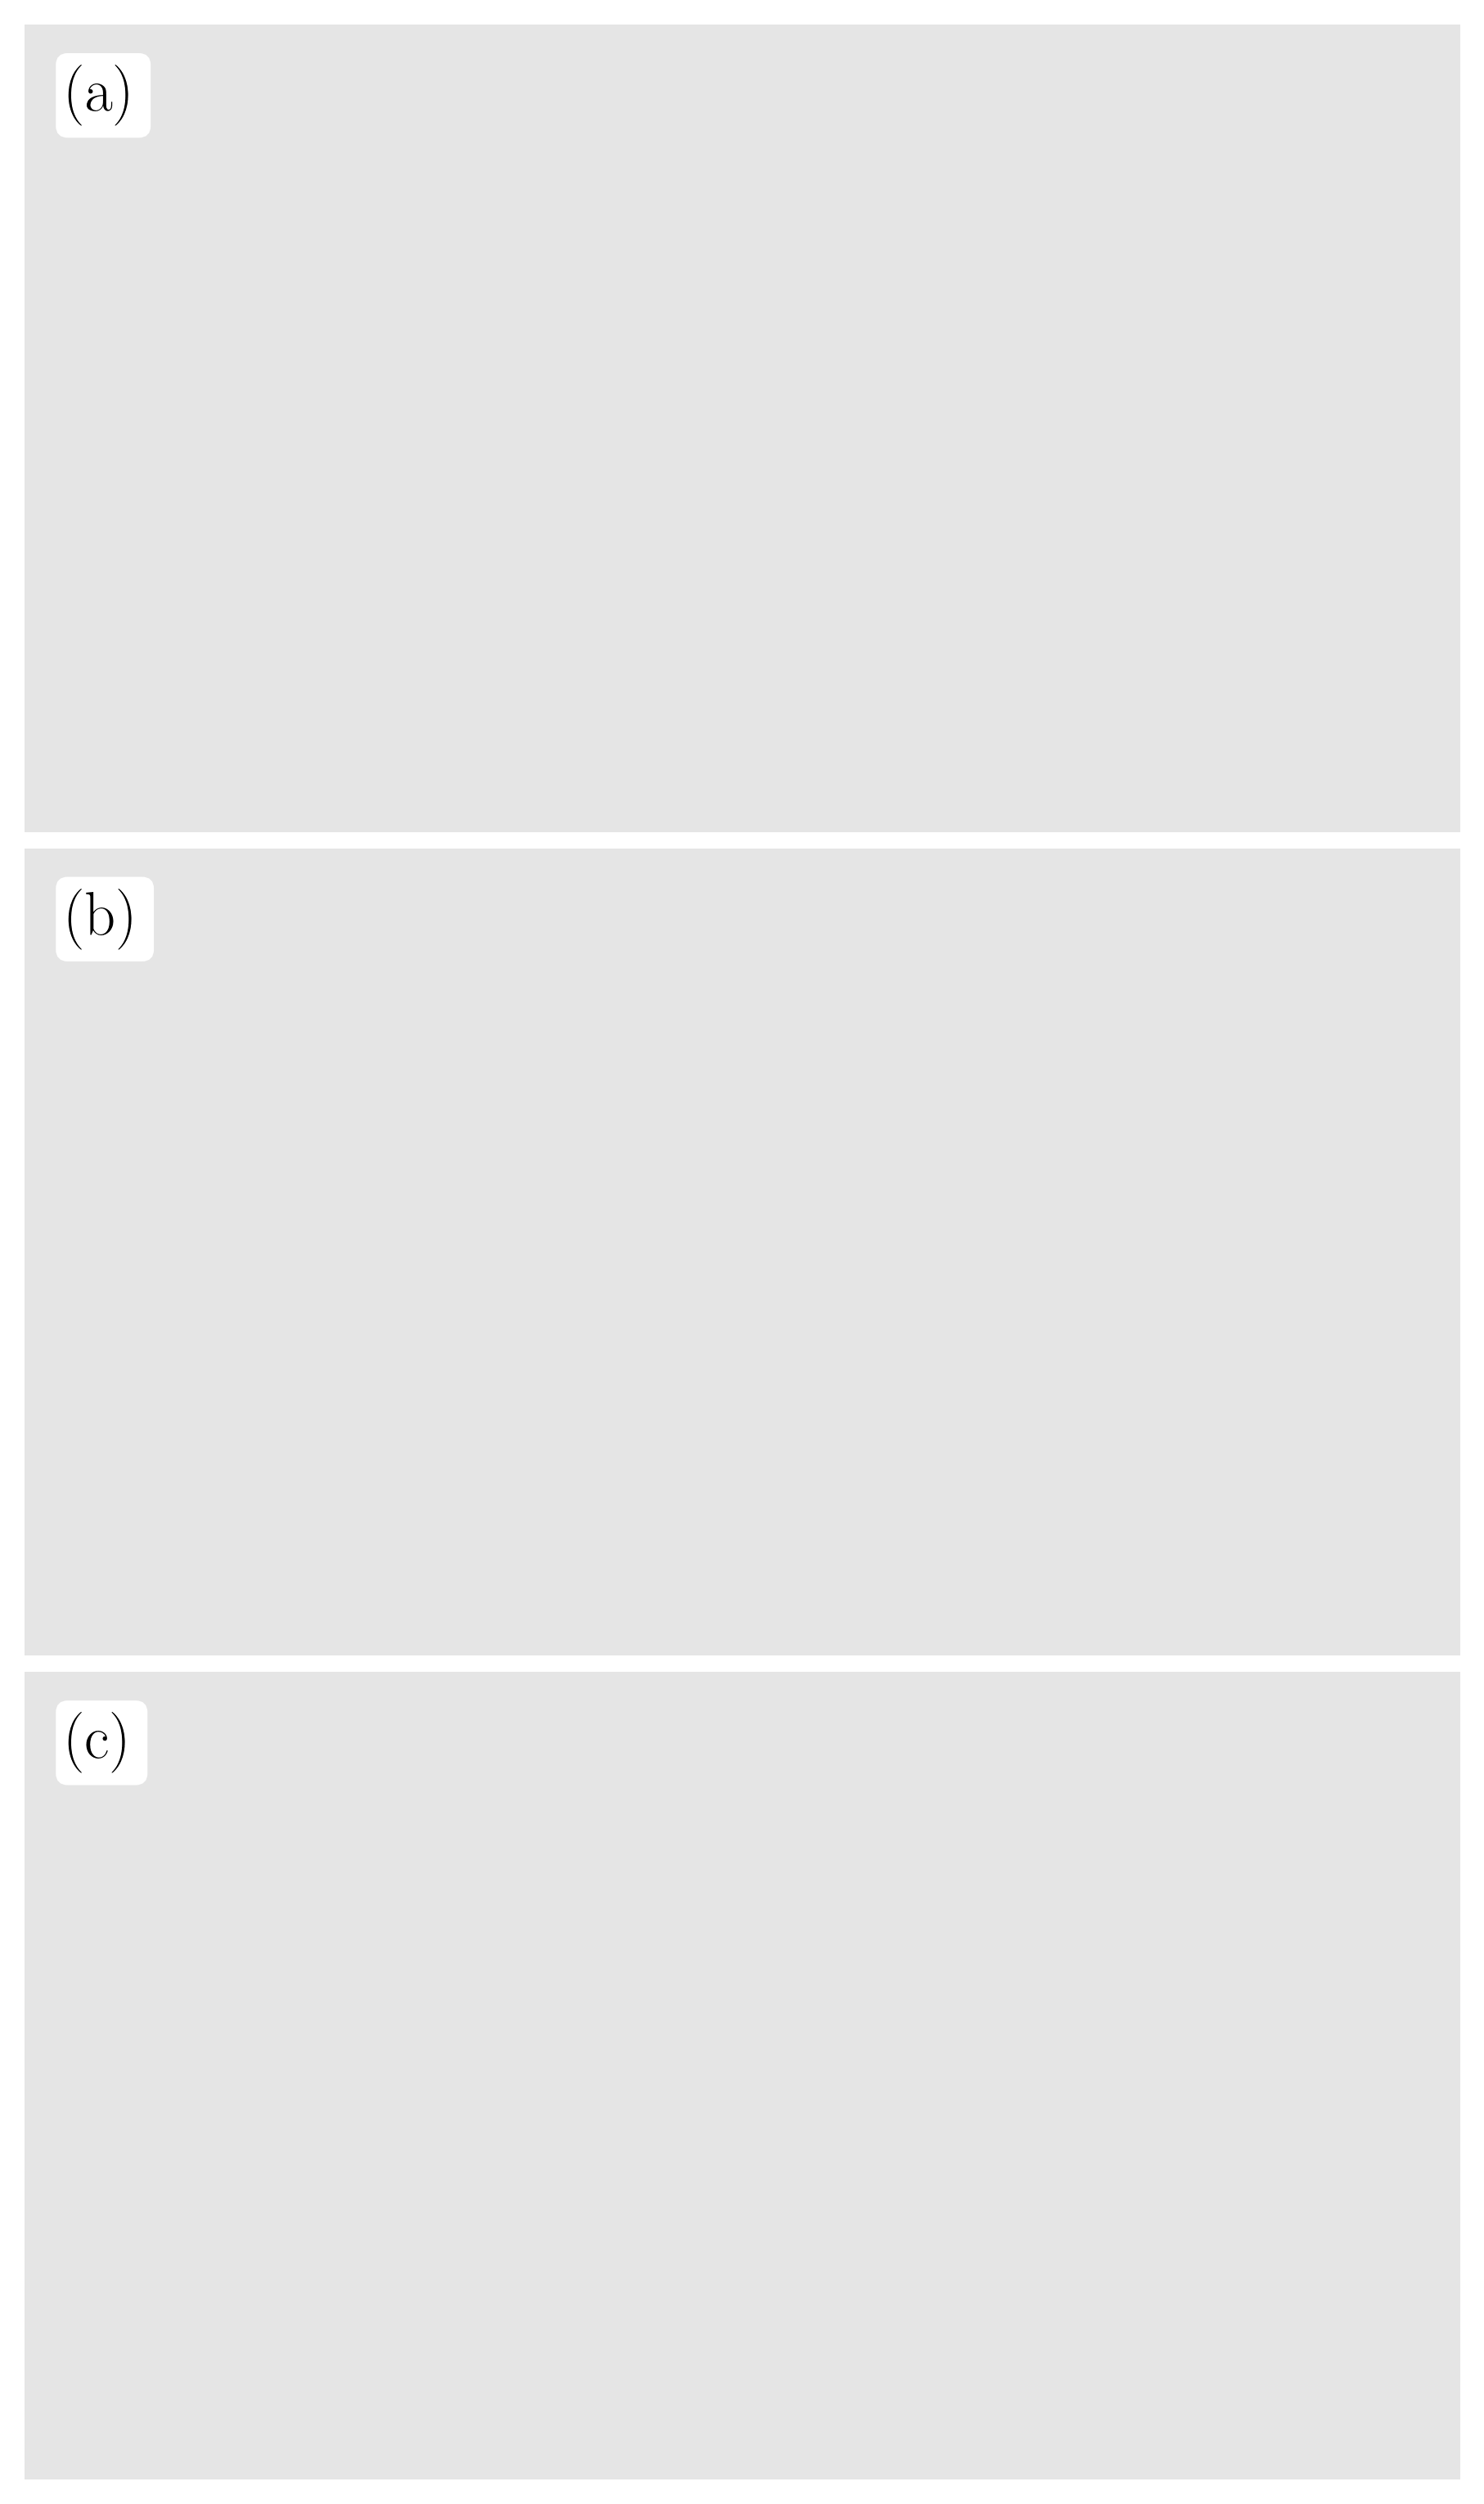

In [ ]:
"""
Vertical stack layout (3 images):

[ img0 ]
[ img1 ]
[ img2 ]

- Cropping is supported per image using PER_RIGHT_IMAGE_CROP (reused from your script).
- Font settings are unchanged from your pasted code.
"""

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec, font_manager

# ================== User parameters (edit these) ==================

# Input / output
INPUT_DIR = "/home/kkondo/paper_writing/DYNUS_v3/figures/sim/standardized"
FILENAMES = [
    "standardized_screenshot.png",
    "standardized_loop2.png",
    "standardized_loop3.png"
]
OUTPUT_DIR = INPUT_DIR
OUTPUT_NAME = "combined_standardized.png"

# Figure
FIG_DPI = 300
FIG_W_IN = 7.0
FIG_H_IN = 10.0

# Spacing
HSPACE = 0.02

# Row size ratios for the 3 stacked images (top/mid/bot)
ROW_RATIOS = [1.0, 1.0, 1.0]

# --------- Cropping (pixels) ---------
# We reuse your existing crop list as per-image crop for the 3 stacked images.
# Order corresponds to FILENAMES (img0, img1, img2).
PER_RIGHT_IMAGE_CROP = [
    {"top": 0, "bottom": 0, "left": 0, "right": 0},  # img0
    {"top": 0, "bottom": 0, "left": 0, "right": 0},  # img1
    {"top": 0, "bottom": 0, "left": 0, "right": 0},  # img2
]

# Labels (you can keep 4; code will safely use only first 3)
LABELS = ["(a)", "(b)", "(c)", "(d)"]
LABEL_SIZE = 18
LABEL_COLOR = "black"
LABEL_FAMILY = "Times New Roman"
LABEL_OFFSET_AXES = (0.03, 0.05)

# Label badge style
LABEL_BADGE = True
BADGE_FACE = "white"
BADGE_EDGE = "white"
BADGE_ALPHA = 1.0
BADGE_LINEWIDTH = 1.5
BADGE_PAD = 0.15
BADGE_ROUNDING = 0.15

# Fonts / TeX
USE_TEX = False
TNR_TTF_PATH = None

# Placeholder if an image is missing (so script still runs)
PLACEHOLDER_H = 540
PLACEHOLDER_W = 960
PLACEHOLDER_GRAY = 0.90

# ================== End user parameters ==================


def _apply_fonts():
    # UNCHANGED from your pasted code
    plt.rcParams.update({"text.usetex": USE_TEX})
    if TNR_TTF_PATH is not None and os.path.exists(TNR_TTF_PATH):
        font_manager.fontManager.addfont(TNR_TTF_PATH)
    font = font_manager.FontProperties()
    font.set_family('serif')
    font.set_size(LABEL_SIZE)
    plt.rcParams.update({"text.usetex": True})
    plt.rcParams["font.family"] = LABEL_FAMILY


def _read_image(path: str) -> np.ndarray:
    img = plt.imread(path)
    if img is None:
        raise FileNotFoundError(f"Could not read: {path}")
    if img.ndim == 2:
        img = np.stack([img] * 3, axis=-1)
    if img.shape[-1] == 4:
        img = img[..., :3]
    return img


def _crop_image(img: np.ndarray, top: int, bottom: int, left: int, right: int) -> np.ndarray:
    h, w = img.shape[0], img.shape[1]
    top = int(max(0, min(top, h - 1)))
    bottom = int(max(0, min(bottom, h - 1)))
    left = int(max(0, min(left, w - 1)))
    right = int(max(0, min(right, w - 1)))

    if top + bottom >= h:
        top = h // 4
        bottom = h // 4
    if left + right >= w:
        left = w // 4
        right = w // 4

    return img[top : h - bottom, left : w - right, :]


def _get_crop_from_dict(d: dict, fallback: dict):
    return (
        d.get("top", fallback.get("top", 0)),
        d.get("bottom", fallback.get("bottom", 0)),
        d.get("left", fallback.get("left", 0)),
        d.get("right", fallback.get("right", 0)),
    )


def _get_image_crop(i: int):
    # Use PER_RIGHT_IMAGE_CROP as per-image crop; if not provided, fallback to zeros.
    fallback = {"top": 0, "bottom": 0, "left": 0, "right": 0}

    if PER_RIGHT_IMAGE_CROP is None:
        d = fallback
    else:
        if len(PER_RIGHT_IMAGE_CROP) < len(FILENAMES):
            raise ValueError("PER_RIGHT_IMAGE_CROP must have at least len(FILENAMES) entries (or be None).")
        d = PER_RIGHT_IMAGE_CROP[i]
        if d is None:
            d = fallback

    return _get_crop_from_dict(d, fallback)


def _load_images_with_crop():
    images = []
    for i, name in enumerate(FILENAMES):
        path = os.path.join(INPUT_DIR, name)

        if not os.path.exists(path):
            ph = np.full((PLACEHOLDER_H, PLACEHOLDER_W, 3), PLACEHOLDER_GRAY, dtype=float)
            images.append(ph)
            print(f"[WARN] Missing file, using placeholder: {path}")
            continue

        img = _read_image(path)
        t, b, l, r = _get_image_crop(i)
        img = _crop_image(img, t, b, l, r)
        images.append(img)

    return images


def _add_label(ax, text: str):
    x = LABEL_OFFSET_AXES[0]
    y = 1.0 - LABEL_OFFSET_AXES[1]

    bbox = None
    if LABEL_BADGE:
        bbox = dict(
            boxstyle=f"round,pad={BADGE_PAD},rounding_size={BADGE_ROUNDING}",
            facecolor=BADGE_FACE,
            edgecolor=BADGE_EDGE,
            linewidth=BADGE_LINEWIDTH,
            alpha=BADGE_ALPHA,
        )

    ax.text(
        x, y, text,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=LABEL_SIZE,
        color=LABEL_COLOR,
        family=LABEL_FAMILY,
        bbox=bbox,
        zorder=5,
    )


# ================== Run (Jupyter cell) ==================
_apply_fonts()

if len(FILENAMES) != 3:
    raise ValueError("This vertical-stack script expects exactly 3 images in FILENAMES.")

imgs = _load_images_with_crop()

# Use only the first 3 labels; if you provided fewer, auto-generate missing ones.
labels3 = (LABELS[:3] if len(LABELS) >= 3 else LABELS + [f"({chr(ord('a')+i)})" for i in range(len(LABELS), 3)])

fig = plt.figure(figsize=(FIG_W_IN, FIG_H_IN), dpi=FIG_DPI, facecolor="white")

gs = gridspec.GridSpec(
    3, 1,
    figure=fig,
    height_ratios=ROW_RATIOS,
    hspace=HSPACE,
)

axes = [fig.add_subplot(gs[i, 0]) for i in range(3)]

for ax, img, lab in zip(axes, imgs, labels3):
    ax.imshow(img)
    ax.axis("off")
    _add_label(ax, lab)

os.makedirs(OUTPUT_DIR, exist_ok=True)
save_path = os.path.join(OUTPUT_DIR, OUTPUT_NAME)

fig.subplots_adjust(left=0.0, right=1.0, bottom=0.0, top=1.0, hspace=HSPACE)
fig.savefig(save_path, bbox_inches="tight", pad_inches=0.0, facecolor="white")
print(f"[OK] Saved: {save_path}")

plt.show()
